In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import jax


In [3]:
#load data
data = np.load("green_machine_results_narma.npz", allow_pickle=True)["results"]

In [4]:
#unwrap dictionary from numpy object array
def unwrap_dict(x):
    
    if isinstance(x, dict):
        return x
    
    if isinstance(x, np.ndarray) and x.dtype == object:
        if x.ndim == 0:
            return x.item()          
        elif x.ndim == 1 and x.size == 1:
            return x[0]
    raise TypeError(f"Don't know how to unwrap type: {type(x)} (dtype={getattr(x,'dtype',None)})")

l = unwrap_dict(data)
print("top-level keys:", list(l.keys()))
keys = l.keys()
mask = []
for key in keys:
    if "in" in key:
        mask.append(key)
print(mask)
for key in mask:
    l.pop(key)
print(l.keys())

top-level keys: ['out0', 'out4', 'out1', 'out5', 'out2', 'out6', 'out3', 'out7']
[]
dict_keys(['out0', 'out4', 'out1', 'out5', 'out2', 'out6', 'out3', 'out7'])


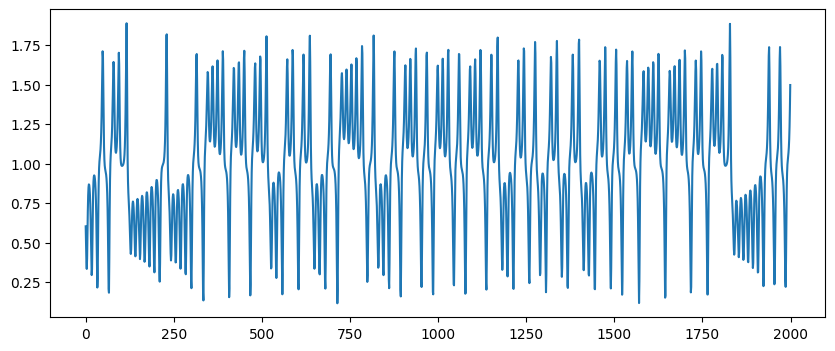

10000
10000


In [8]:
sigma, rho, beta = 10.0, 28.0, 8/3
N = 10000
dtt = 0.05
upsample = 1
factor = 10

# Lorenz system
def lorenz(t, xyz):
    x, y, z = xyz
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

T = dtt * (N - 1)
dt_fine = dtt / upsample
t_fine = np.arange(0.0, T + 1e-12, dt_fine)

sol = solve_ivp(
    lorenz, (0.0, T), (0., 1., 1.05),
    method="RK45", max_step=dt_fine, t_eval=t_fine
)
x_f, y_f, z_f = sol.y

def minmax(u):
    return (u - u.min())/(u.max() - u.min())

# normalize each axis independently
x_lorenz = minmax(x_f)
y_lorenz = minmax(y_f)
y = minmax(z_f)
combined_sig = x_lorenz + y_lorenz
plt.figure(figsize=(10,4))
plt.plot(combined_sig[1000:3000])
plt.show()

print(len(y))


def narma7(N, seed=0, u_low=0.0, u_high=0.5, burn_in=1000):
    rng = np.random.default_rng(seed)
    U = rng.uniform(u_low, u_high, size=N + burn_in + 10)
    Y = np.zeros_like(U)
    for t in range(6, N + burn_in): 
        s = np.sum(Y[t-6:t+1])       
        Y[t+1] = 0.3 * Y[t] + 0.05 * Y[t] * s + 1.5 * U[t-6] * U[t] + 0.1
    u = U[burn_in+1:burn_in+1+N]
    y = Y[burn_in+1:burn_in+1+N]
    return u, y

u,y_narma = narma7(N, seed=42)
print(len(y_narma))



In [67]:
#prepare data for neural network
X = np.stack(
    [v["output"].amplitude[214::512, :, 0] for v in l.values()],
    axis=0
)
X = X.transpose(1, 2, 0)
print("X shape:", X.shape)
X =X.reshape(X.shape[0], int(X.shape[1]*X.shape[2]))
print("X reshaped shape:", X.shape)


X shape: (10000, 5, 8)
X reshaped shape: (10000, 40)


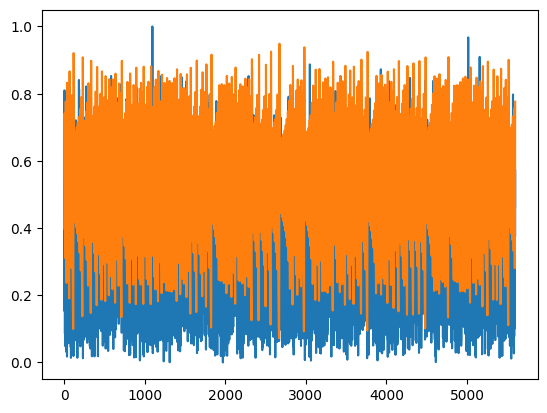

(5599, 40) (800, 40) (1600, 40)
(5599,) (800,) (1600,)


In [ ]:
#data preprocessing functions

def data_shape(data, delay=0, sps=1, time_multiplex_var=50):
    x = data() if callable(data) else data
    per_symbol = x[delay::sps, :]
    n_sym, n_ch = per_symbol.shape
    n_blocks = n_sym // time_multiplex_var
    per_symbol = per_symbol[:n_blocks * time_multiplex_var]
    X = per_symbol.reshape(n_blocks, time_multiplex_var * n_ch)
    return X

def train_test_split_embargo(X,train_frac = 0.7,validation_frac=0.2,test_frac = 0.1, embargo = 0):
    N = X.shape[0]
    split_train = int(np.floor(train_frac * N))
    split_val = int(np.floor((train_frac + validation_frac) * N))
    lo = max(0, split_train - embargo)
    mid = min(N, split_train + embargo)
    hi = min(N, split_val + embargo)
    X_train = X[0:lo]
    X_validation = X[mid:hi]
    X_test = X[hi:]

    return X_train, X_validation, X_test

def train_test_split_labels(y,train_frac = 0.7, validation_frac=0.2, test_frac=0.1, embargo = 0):
    N = len(y)
    split_train = int(np.floor(train_frac * N))
    split_val = int(np.floor((train_frac + validation_frac) * N))
    lo = max(0, split_train - embargo)
    mid = min(N, split_train + embargo)
    hi = min(N, split_val + embargo)
    Y_train = y[0:lo]
    Y_validation = y[mid:hi]
    Y_test = y[hi:]
    return Y_train, Y_validation, Y_test


X_train, X_validation, X_test = train_test_split_embargo(X[1000:-1001], train_frac=0.7, validation_frac=0.2, test_frac=0.1)
Y_train, Y_validation, Y_test = train_test_split_labels(y[1001:-1000], train_frac=0.7,validation_frac=0.2)

#normalize data
umin = X_train.min(axis=0, keepdims=True)
umax = X_train.max(axis=0, keepdims=True)
X_train = (X_train - umin) / (umax - umin + 1e-12)
X_validation = (X_validation - umin) / (umax - umin + 1e-12)
X_test = (X_test - umin) / (umax - umin + 1e-12)
print(X_train.shape,X_test.shape,X_validation.shape)
print(Y_train.shape,Y_test.shape,Y_validation.shape)

In [69]:
#define neural network model
class InterferometricRegressor(nn.Module):
    def __init__(self, n_pos, n_neg):
        super().__init__()
        self.wpos = nn.Parameter(torch.randn(n_pos, dtype=torch.cfloat))
        self.wneg = nn.Parameter(torch.randn(n_neg, dtype=torch.cfloat))
        self.bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, xpos, xneg):
        pos = torch.sum(self.wpos * xpos, dim=1)
        neg = torch.sum(self.wneg * xneg, dim=1)
        return pos.abs()**2 - neg.abs()**2 + self.bias

Y_train_np = np.array(Y_train, copy=True)
Y_test_np  = np.array(Y_validation,  copy=True)

xpos_train, xneg_train = X_train[:,:20], X_train[:,20:40]
xpos_test, xneg_test = X_validation[:,:20], X_validation[:,20:40]

xpos_train_torch = torch.tensor(xpos_train, dtype=torch.cfloat)
xneg_train_torch = torch.tensor(xneg_train, dtype=torch.cfloat)
y_train_torch = torch.tensor(Y_train_np, dtype=torch.float32)

xpos_test_torch = torch.tensor(xpos_test, dtype=torch.cfloat)
xneg_test_torch = torch.tensor(xneg_test, dtype=torch.cfloat)
y_test_torch = torch.tensor(Y_test_np, dtype=torch.float32)

model = InterferometricRegressor(
    n_pos = xpos_train.shape[1],
    n_neg = xneg_train.shape[1]
)

mse_loss = nn.MSELoss()

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,            
    max_iter=100,       
    history_size=100,
    line_search_fn='strong_wolfe',
    tolerance_grad=1e-10,
    tolerance_change=1e-10,

)
path = "model.pth"
def closure():
    optimizer.zero_grad()
    y_pred = model(xpos_train_torch, xneg_train_torch)
    loss = mse_loss(y_pred, y_train_torch)
    loss.backward()
    return loss

best_r2_test = 0
n_epochs = 25
for epoch in range(n_epochs):
    
    loss = optimizer.step(closure)  # after this, params have changed

    model.eval()
    with torch.no_grad():
        y_pred_train = model(xpos_train_torch, xneg_train_torch)
        y_pred_test  = model(xpos_test_torch,  xneg_test_torch)

        train_mse = mse_loss(y_pred_train, y_train_torch)
        test_mse  = mse_loss(y_pred_test,  y_test_torch)

        train_rmse = torch.sqrt(train_mse + 1e-6).item()
        test_rmse  = torch.sqrt(test_mse + 1e-6).item()

        r2_train = (1 - torch.sum((y_train_torch - y_pred_train)**2) /
                        torch.sum((y_train_torch - y_train_torch.mean())**2)).item()
        r2_test  = (1 - torch.sum((y_test_torch  - y_pred_test )**2) /
                        torch.sum((y_test_torch  - y_test_torch.mean())**2)).item()
        
        if r2_test > best_r2_test:
            best_r2_test = r2_test
            
            torch.save(model, path)
            print(f"New best model saved with Test R² = {best_r2_test:.6f}")
        
        

    print(f"Step {epoch+1}: "
        f"Train RMSE = {train_rmse:.6f}, Test RMSE = {test_rmse:.6f}, "
        f"Train R² = {r2_train:.6f}, Test R² = {r2_test:.6f}")
    

model1 = torch.load(path,weights_only=False, map_location="cpu")
device = next(model1.parameters()).device
dtype = next(model1.parameters()).dtype

def to_torch(x):
    x = np.asarray(x)
    if np.iscomplexobj(x) and dtype.is_floating_point:
        x = x.real
    t = torch.from_numpy(x)
    if t.dtype == torch.float64 and dtype == torch.float32:
        t = t.float()
    if t.dtype == torch.complex128 and dtype == torch.complex64:
        t = t.to(torch.complex64)
    return t.to(device=device, dtype=dtype)
xpos_final,xneg_final = X_test[:,:20],X_test[:,20:40]
xpos_final_t = to_torch(xpos_final)
xneg_final_t = to_torch(xneg_final)

y_final_t = torch.tensor(Y_test,dtype=torch.float32)

with torch.no_grad():
    y_final_pred_t = model1(xpos_final_t, xneg_final_t)
    y_final_pred_r_model = model(xpos_final_t, xneg_final_t)
    

r2_final_test = 1-torch.sum((y_final_pred_t - y_final_t)**2) / torch.sum((y_final_t - y_final_t.mean())**2)
r2_final_r_model = 1-torch.sum((y_final_pred_r_model - y_final_t)**2) / torch.sum((y_final_t - y_final_t.mean())**2)
print(f"Final Test R² = {r2_final_test:.6f}")
print(f"Final Test R² (R model) = {r2_final_r_model:.6f}")

Step 1: Train RMSE = 0.183229, Test RMSE = 0.185147, Train R² = 0.010212, Test R² = -0.013766
Step 2: Train RMSE = 0.182975, Test RMSE = 0.191123, Train R² = 0.012952, Test R² = -0.080271
Step 3: Train RMSE = 0.182879, Test RMSE = 0.189100, Train R² = 0.013987, Test R² = -0.057521
Step 4: Train RMSE = 0.182834, Test RMSE = 0.189816, Train R² = 0.014478, Test R² = -0.065540
Step 5: Train RMSE = 0.182760, Test RMSE = 0.190170, Train R² = 0.015266, Test R² = -0.069524
Step 6: Train RMSE = 0.182716, Test RMSE = 0.189671, Train R² = 0.015748, Test R² = -0.063913
Step 7: Train RMSE = 0.182715, Test RMSE = 0.189206, Train R² = 0.015760, Test R² = -0.058702
Step 8: Train RMSE = 0.182699, Test RMSE = 0.188356, Train R² = 0.015928, Test R² = -0.049216
Step 9: Train RMSE = 0.182621, Test RMSE = 0.186649, Train R² = 0.016764, Test R² = -0.030278
Step 10: Train RMSE = 0.182593, Test RMSE = 0.186283, Train R² = 0.017075, Test R² = -0.026241
Step 11: Train RMSE = 0.182560, Test RMSE = 0.186406, Train

Parameter containing:
tensor([ 2.0466e-02+4.1116e-03j, -2.9072e-02+8.1195e-03j,
        -3.7065e-03-6.4338e-02j, -4.3251e-02-7.0434e-02j,
        -2.7848e+00-3.3111e+00j, -3.9112e+00+4.5237e+00j,
        -5.8175e+00+2.9270e+00j, -3.7511e+00-3.0448e+00j,
        -1.5621e+00-4.4352e+00j,  4.5203e+00-2.4941e+00j,
         5.7891e+00+2.9452e-01j, -3.2503e+00-3.6954e+00j,
         3.5364e+00+3.3784e+00j,  2.1249e+00-3.8516e+00j,
         1.6863e+00-4.0639e+00j,  3.2749e+00+2.9192e+00j,
         3.2228e+00+6.7203e+00j, -3.1334e+00+3.6290e+00j,
        -3.6689e+00+7.7452e-01j,  4.5287e+00+1.2686e+00j], requires_grad=True)
Parameter containing:
tensor([ 2.0489e+00+1.7813e+00j, -8.4068e+00+1.0011e+01j,
        -4.5769e+00+6.0337e-01j, -4.1996e+00+1.1429e+00j,
         2.5876e+00+9.8272e-01j, -4.0787e+00-1.0094e+01j,
         1.4879e+00-1.2405e+01j, -3.3453e+00+6.3092e+00j,
         2.2084e+00-7.3870e-01j,  2.2909e+00+1.1206e+01j,
        -2.4046e-01+1.0690e+01j, -5.7420e-01+9.0611e+00j,
       

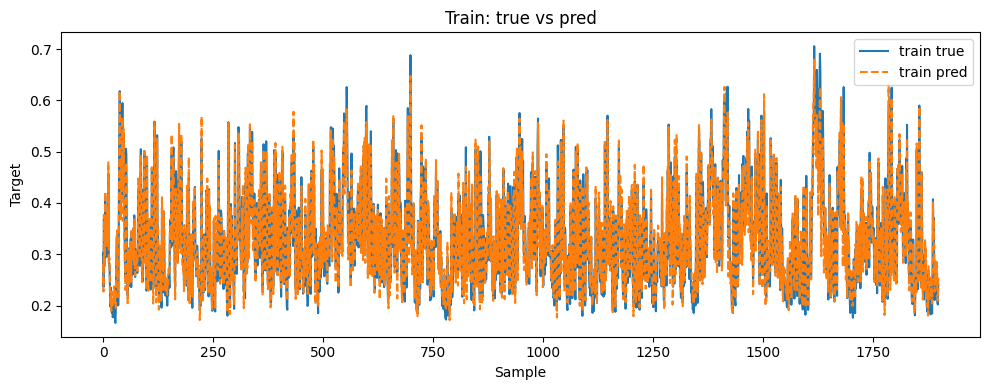

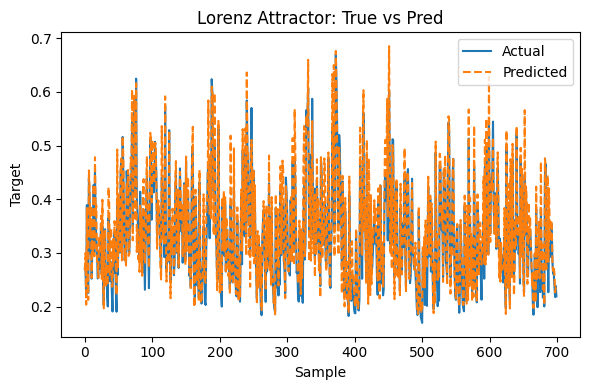

In [61]:
#load best model and make predictions
model = torch.load(path,weights_only=False, map_location="cpu")

device = next(model.parameters()).device
dtype = next(model.parameters()).dtype

def to_torch(x):
    x = np.asarray(x)
    if np.iscomplexobj(x) and dtype.is_floating_point:
        x = x.real
    t = torch.from_numpy(x)
    if t.dtype == torch.float64 and dtype == torch.float32:
        t = t.float()
    if t.dtype == torch.complex128 and dtype == torch.complex64:
        t = t.to(torch.complex64)
    return t.to(device=device, dtype=dtype)

xpos_train_t = to_torch(xpos_train)
xneg_train_t = to_torch(xneg_train)
xpos_test_t  = to_torch(xpos_final)
xneg_test_t  = to_torch(xneg_final)

with torch.no_grad():
    y_tr_pred_t = model(xpos_train_t, xneg_train_t)
    y_te_pred_t = model(xpos_test_t,  xneg_test_t)
print(model.wneg)
print(model.wpos)
print(model.bias)
y_tr_pred = y_tr_pred_t.squeeze(-1).detach().cpu().numpy()
y_te_pred = y_te_pred_t.squeeze(-1).detach().cpu().numpy()

y_tr_true = y_train_torch.detach().cpu().numpy()
y_te_true = y_final_t.detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.plot(y_tr_true[100:2000], label="train true")
plt.plot(y_tr_pred[100:2000], label="train pred",linestyle='--')
plt.xlabel("Sample"); plt.ylabel("Target"); plt.title("Train: true vs pred")
plt.legend(); plt.tight_layout()

plt.figure(figsize=(6,4))
plt.plot(y_te_true[100:], label="Actual")
plt.plot(y_te_pred[100:], label="Predicted",linestyle='--')
plt.xlabel("Sample"); plt.ylabel("Target"); plt.title("Lorenz Attractor: True vs Pred")
plt.legend(); plt.tight_layout()

factor = 10
x_lorenz min/max: 0.0 1.0
y_lorenz min/max: 0.0 1.0
z_lorenz min/max: 0.0 1.0
length of x_lorenz: 10000
t_new[-1] = 9999.0


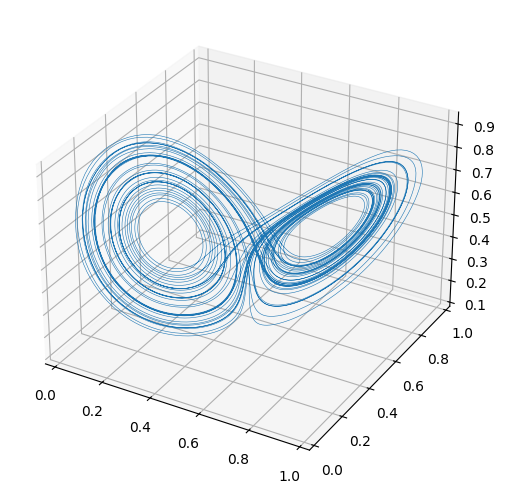

In [73]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# parameters from your code
sigma, rho, beta = 10.0, 28.0, 8/3
N = 10000
dtt = 0.05
upsample = 1
factor = 10

# Lorenz system
def lorenz(t, xyz):
    x, y, z = xyz
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

T = dtt * (N - 1)
dt_fine = dtt / upsample
t_fine = np.arange(0.0, T + 1e-12, dt_fine)

sol = solve_ivp(
    lorenz, (0.0, T), (0., 1., 1.05),
    method="RK45", max_step=dt_fine, t_eval=t_fine
)
x_f, y_f, z_f = sol.y

def minmax(u):
    return (u - u.min())/(u.max() - u.min())

# normalize each axis independently
x_lorenz = minmax(x_f)
y_lorenz = minmax(y_f)
z_lorenz = minmax(z_f)

# interpolation setup
n = len(x_lorenz)
t = np.arange(n)
t_new = np.linspace(0, n - 1, n * factor)

fx = interp1d(t, x_lorenz, kind='cubic')
fy = interp1d(t, y_lorenz, kind='cubic')
fz = interp1d(t, z_lorenz, kind='cubic')

x_new = fx(t_new)
y_new = fy(t_new)
z_new = fz(t_new)

# slice exactly as your original code
sl = slice(10000, 20000)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x_new[sl], y_new[sl], z_new[sl], linewidth=0.4)
plt.tight_layout()
print("factor =", factor)
print("x_lorenz min/max:", x_lorenz.min(), x_lorenz.max())
print("y_lorenz min/max:", y_lorenz.min(), y_lorenz.max())
print("z_lorenz min/max:", y.min(), y.max())
print("length of x_lorenz:", len(x_lorenz))
print("t_new[-1] =", t_new[-1])


In [74]:
import scipy, numpy as np
scipy.__version__, np.__version__

('1.15.2', '2.2.5')

(55990,)


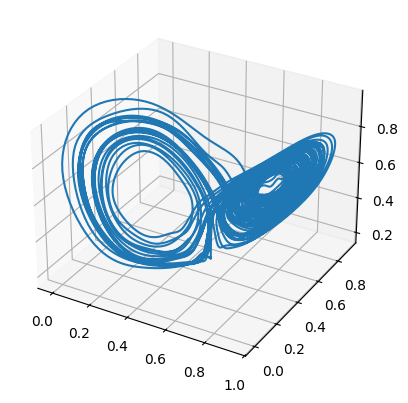

In [165]:
print(z_pred.shape)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x_new[10010:20010], y_new[10010:20010], z_pred[0:10000])
plt.show()